In [55]:
import numpy as np
import matplotlib.pyplot as plt


In [56]:
import numpy as np
import pyvista as pv
import meshio
from time import time


class LinearArrayTransducer:
    def __init__(
        self,
        *,
        n_elements,
        element_width_mm,
        element_height_mm,
        kerf_mm,
        elevation_focus_mm,
        no_sub_x,
        no_sub_y,
        frequency_Hz = None
    ):
        """
        Defines a linear array transducer geometry with optional elevation focusing.

        Parameters
        ----------
        n_elements : int
            Number of elements in the array.
        element_width : float
            Width of each element (m).
        element_height : float
            Height of each element (m).
        kerf : float
            Gap between elements (m).
        elevation_focus : float or None
            Elevation focus distance (m). If None, elements are flat.
        no_sub_x, no_sub_y : int
            Number of subdivisions (patches) in x (element width) and y (element height).
            
        """
        start_time = time()
        element_height, element_width = element_height_mm / 1000.0, element_width_mm / 1000.0
        kerf, elevation_focus = kerf_mm / 1000.0, elevation_focus_mm / 1000.0
        self.n_elements = n_elements
        self.el_w = element_width
        self.el_h = element_height
        self.kerf = kerf
        self.elev_focus = elevation_focus
        self.no_sub_x = no_sub_x
        self.no_sub_y = no_sub_y
        if frequency_Hz is not None:
            self.fc = frequency_Hz
        else:
            self.fs = 1
            print("Warning: No central frequency provided. Defaulting to 1 Hz.")

        # Per-element apodization weights and delay placeholders
        self.apodization = np.ones(n_elements, dtype=float)
        self.delays = np.zeros(n_elements, dtype=float)

        # Compute element centers along x-axis
        total_width = n_elements * element_width + (n_elements - 1) * kerf
        start_x = -total_width / 2 + element_width / 2
        self.element_centers = np.array([
            [start_x + i * (element_width + kerf), 0.0, 0.0]
            for i in range(n_elements)
        ])

        # Build subdivisions boundaries and areas, apply elevation curvature
        self.sub_quad_verts, self.sub_area, self.sub_el_idx = self._build_subdivisions()
        end_time = time()
        print(f"Transducer initialized in {end_time - start_time:.4f} seconds.")

    def _build_subdivisions(self):
        """
        Generate vertices for each subdivision quad of each element, applying elevation focus curvature if set.
        Returns
        -------
        sub_quad_verts : list of arrays (4x3) for each patch quad vertices
        sub_area : float, area of each patch
        sub_el_idx : list mapping each patch to its element index
        """
        # Local grid edges in element coordinates
        xs = np.linspace(-self.el_w/2, self.el_w/2, self.no_sub_x + 1)
        ys = np.linspace(-self.el_h/2, self.el_h/2, self.no_sub_y + 1)

        patch_area = (self.el_w / self.no_sub_x) * (self.el_h / self.no_sub_y)

        quads = []
        el_indices = []
        for idx, center in enumerate(self.element_centers):
            for i in range(self.no_sub_x):
                for j in range(self.no_sub_y):
                    # four corners of the patch in local coords
                    corners_local = np.array([
                        [xs[i],   ys[j],   0.0],
                        [xs[i+1], ys[j],   0.0],
                        [xs[i+1], ys[j+1], 0.0],
                        [xs[i],   ys[j+1], 0.0]
                    ])
                    # translate to global x,y
                    corners = corners_local.copy()
                    corners[:,0] += center[0]
                    corners[:,1] += center[1]
                    # apply elevation curvature in z
                    if self.elev_focus is not None and self.elev_focus > 0:
                        y_vals = corners[:,1]
                        z_offset = self.elev_focus - np.sqrt(np.clip(self.elev_focus**2 - y_vals**2, 0, None))
                        corners[:,2] += z_offset
                    else:
                        corners[:,2] += center[2]
                    quads.append(corners)
                    el_indices.append(idx)
        return quads, patch_area, el_indices

    def set_apodization(self, weights):
        """Set per-element apodization weights (length = n_elements)."""
        weights = np.asarray(weights, dtype=float)
        if weights.shape[0] != self.n_elements:
            raise ValueError("Apodization array must match number of elements.")
        self.apodization = weights

    def set_delays(self, delays):
        """Set per-element delays in seconds (length = n_elements)."""
        delays = np.asarray(delays, dtype=float)
        if delays.shape[0] != self.n_elements:
            raise ValueError("Delay array must match number of elements.")
        self.delays = delays

    def get_mesh(self):
        """
        Returns a PyVista PolyData mesh of all subdivided quads, with per-cell apodization scalars.
        """
        # Aggregate all points and faces
        verts = []
        faces = []
        scalars = []
        pt_index = 0
        for quad, el_idx in zip(self.sub_quad_verts, self.sub_el_idx):
            # quad is 4x3 array, create face [4, p0, p1, p2, p3]
            verts.extend(quad.tolist())
            face = [4, pt_index, pt_index+1, pt_index+2, pt_index+3]
            faces.append(face)
            scalars.append(self.apodization[el_idx])
            pt_index += 4
        # Flatten verts and faces
        verts = np.array(verts)*1e3  # Convert to mm for visualization
        faces_flat = np.hstack(faces)
        mesh = pv.PolyData(verts, faces_flat)
        mesh.cell_data['Apodization'] = np.array(scalars)
        return mesh


In [57]:
from scipy.interpolate import interp1d

def _compute_rectangle_SIR(wx,wy,xp,yp,l,c0, apodization, delay) :
    """
    Compute the SIR (Spatial impulse Response) for a rectangle defined by its center and corners.
    The SIR is computed with the far-field approximation.
    """
    # print(f"wx: {wx}, wy: {wy}, xp: {xp}, yp: {yp}, l: {l}, c0: {c0}, apodization: {apodization}, delay: {delay}")
    # Compute the normal vector of the rectangle
    Dt1 = min(wx*xp/c0, wy*yp/c0) # Convert to microseconds
    Dt2 = max(wx*xp/c0, wy*yp/c0) 

    # print(f"Dt1: {1/Dt1:.2e} us, Dt2: {1/Dt2:.2e} us")
    area = wx*wy/(2*np.pi*l)

    t1 = l/c0 - (Dt1 + Dt2)/ 2 # us
    t2 = t1 + Dt1 # us
    t3 = t1 + Dt2 # us
    t4 = t1 +  Dt1 + Dt2 # us

    t = np.array([t1,t2,t3,t4]) + delay
    h = np.array([0, area, area, 0])*apodization
    
    return t, h

class PyField:
    def __init__(self, transducer):
        """
        Computational framework for ultrasound fields. Wraps a transducer object.
        """
        self.tx = transducer
        self.c = 1540.0  # Speed of sound in soft tissue (m/s)
        self.fs = 100e6 # Sampling frequency (Hz)
        self.t_max = 50e-6  # Max time for field computation

        self.use_attenuation = False  # Flag for attenuation computation
        self.att_f0 = transducer.fc  # Central frequency for attenuation
        self.f_wv = transducer.fc  # Frequency for field computation
        self.lambda_wv = self.c / self.f_wv # Wavelength (um)

        # Frequency independent attenuation at the frequency f0 [dB/m]
        self.att = 0.5  # Attenuation coefficient (dB/m)

    
    def set_field(self, name_struct_str, value_float):
        """
        Dynamically modifies a class property if it exists.

        Parameters
        ----------
        name_struct_str : str
            The name of the property to modify.
        value_float : float
            The new value to assign to the property.

        Raises
        ------
        AttributeError
            If the property does not exist in the class.
        TypeError
            If the value is not a float.
        """
        if not isinstance(value_float, (float, int)):  # Allow integers as well
            raise TypeError(f"The value must be a float or int, got {type(value_float).__name__}.")
        
        if hasattr(self, name_struct_str):
            setattr(self, name_struct_str, value_float)
            print(f"Property '{name_struct_str}' updated to {value_float}.")
        else:
            raise AttributeError(f"Property '{name_struct_str}' does not exist in the class.")

    def show_transducer(self, kwargs= None):
        """
        Visualize the transducer surface mesh and apodization with PyVista.
        """
        mesh = self.tx.get_mesh()
        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh,  # Convert to mm for visualization
            scalars='Apodization',
            cmap='viridis',
            show_scalar_bar=True,
            scalar_bar_args={'title':'Apodization', 'vertical': True},
            opacity=1.0,
            show_edges=True,
        )
        plotter.add_axes()
        plotter.show_grid(font_size = 10, xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)", show_zlabels=False)
        plotter.show()

    def spatial_impulse_response(self, field_points, return_all = False):
        """
        Compute the Spatial Impulse Response (SIR) of a linear array transducer at given field points,
        incorporating per-element delays.

        Parameters
        ----------
        transducer : LinearArrayTransducer
            Instance with subdivisions built and optional element delays (s).
        points : ndarray, shape (P, 3)
            Field points in meters where SIR is evaluated.
        c : float
            Speed of sound in m/s (default: 1540 m/s).
        fs : float
            Sampling frequency in Hz for the impulse response (default: 100 MHz).
        t_max : float or None
            Maximum time in seconds. If None, set to (max distance + max delay)/c + buffer.

        Returns
        -------
        t : ndarray, shape (N,)
            Time vector for the impulse response.
        h : ndarray, shape (P, N)
            SIR waveform at each of the P points.

        Notes
        -----
        - Each subdivision patch is approximated as a point source located at its centroid.
        - Per-element electronic delays are added to each patch’s propagation delay.
        - Amplitude term: (weight * area) / (2*pi*r*c).
        """
        if field_points.ndim > 2:
            raise ValueError("Field points must be 3D array (P, 3) or (3,).")
        
        pts = np.atleast_2d(field_points)
        P = pts.shape[0]

        sub_elem_h = self.tx.el_h / self.tx.no_sub_y
        sub_elem_w = self.tx.el_w / self.tx.no_sub_x
        largest_dim = max(sub_elem_h, sub_elem_w)
        
        closest_distance = np.linalg.norm(pts, axis=1).min()
        criteria = np.sqrt(closest_distance * self.lambda_wv * 4)
        if largest_dim > 10 * criteria:
            print(f"Warning: The largest dimension ({largest_dim:.2e} m) > 10x criteria ({criteria:.2e} m). Results may be inaccurate.")

        nb_elements = self.tx.n_elements
        nb_sub_div_per_elem = self.tx.no_sub_x * self.tx.no_sub_y
        t_tx = np.zeros((P, nb_elements*nb_sub_div_per_elem, 4))
        h_tx = np.zeros((P, nb_elements*nb_sub_div_per_elem, 4))

        for p in range(P):
            rect_count = 0
            for elem in range(nb_elements):
                for sub_div_per_elem in range(nb_sub_div_per_elem) :
                    # Get the patch center
                    xp, yp, zp = pts[p,:]
                    patch_center = self.tx.sub_quad_verts[elem+sub_div_per_elem].mean(axis=0)
                    point2patch = [xp-patch_center[0], yp-patch_center[1], zp-patch_center[2]]
                    distance_point2patch =  np.linalg.norm(point2patch)
                    point2patch = np.array(point2patch) / distance_point2patch  # Normalize the vector
                    
                    ti, hi =_compute_rectangle_SIR( sub_elem_w, sub_elem_h, point2patch[0], point2patch[1],
                                            distance_point2patch, self.c,
                                            self.tx.apodization[elem], self.tx.delays[elem])
                    t_tx[p, rect_count, :] = ti
                    h_tx[p, rect_count, :] = hi
                    rect_count += 1
                
        start_time, end_time = t_tx.min(), t_tx.max()+ 1/self.fs
        
        # print(f"start_time: {start_time:.2e} s, end_time: {end_time:.2e} s")
        # print(f"time vector {time.shape}")

        time = np.arange(start_time, end_time, 1/self.fs)  # Convert to microseconds
        h_p = np.zeros((P, time.shape[0]))

        for p in range(P):
            for i in range(h_tx.shape[1]):
                # We check if the values of the time vector are all the same
                if np.all(t_tx[p, i, :] == t_tx[p, i, 0]):
                    # We determine the closest time value to the time vector

                    ind_t = np.argmin(np.abs(time - t_tx[p, i, 0]))
                    h_interp = np.zeros(time.shape[0])
                    h_interp[ind_t] = h_tx[p, i, 2] 
                else :
                    h_interp = np.interp(time, t_tx[p, i, :], h_tx[p, i, :])    
                    
                h_p[p,:] += h_interp
        if return_all :
            return time, h_p, t_tx, h_tx, 
        else :
            return start_time, h_p

In [58]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5e6  # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

tx = LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 5,
    frequency_Hz       = tx_freq,  # MHz
)

# Apodization and focusing delays
focus_mm = np.array([0, 0, 8])  # mm
delays = np.linalg.norm(tx.element_centers - focus_mm*1e-3, axis=1) / c
delays = delays.max() - delays  # time delays for focusing
tx.set_delays(delays)
tx.set_apodization(np.hanning(n_elements))


Transducer initialized in 0.0175 seconds.


In [59]:
# Wrap into PyField
field = PyField(tx)

In [60]:
time, h_p, t_tx, h_tx, = field.spatial_impulse_response(focus_mm*1e-3, return_all=True) 

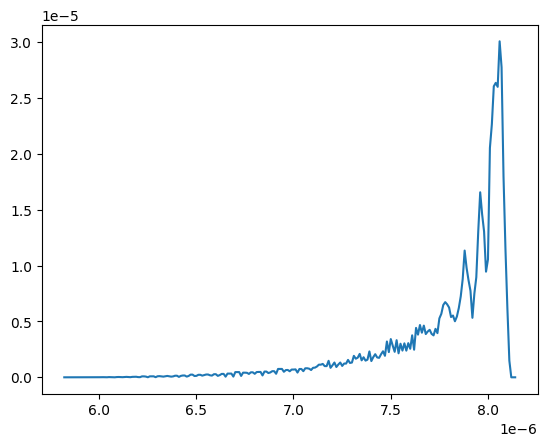

In [78]:
plt.plot(time, h_p.T)

In [63]:

field.show_transducer()

Widget(value='<iframe src="http://localhost:65500/index.html?ui=P_0x25f3e3e6de0_3&reconnect=auto" class="pyvis…

# Multipoint

In [64]:
def create_simulation_grid(simulation_struct):
    """
    Create a simulation mesh for the ultrasound field.
    
    Parameters
    ----------
    simulation_struct : dict
        Dictionary containing the simulation parameters.
    
    Returns
    -------
    grid_points : ndarray
        Array of points in the simulation space.
    """
    # Create a grid of points in the simulation space
    [x0, xf], [y0, yf], [z0, zf] = simulation_struct["x_extent"], simulation_struct["y_extent"], simulation_struct["z_extent"]
    Nx = int((xf-x0) / simulation_struct["dx"])
    Ny = int((yf-y0) / simulation_struct["dy"])
    Nz = int((zf-z0) / simulation_struct["dz"])
    if Nx % 2 == 0 :
        Nx += 1 
    if Ny % 2 == 0 :
        Ny += 1
    if Nz % 2 == 0 :
        Nz += 1

    x = np.linspace(x0,xf, Nx)
    y = np.linspace(y0,yf, Ny)
    z = np.linspace(z0,zf, Nz)
    # Create a meshgrid of points
    grid_points = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)

    return x*1e3, y*1e3, z*1e3, grid_points

In [65]:
simulation_struct = {
    "x_extent" : [-0.5e-3, 0.5e-3],
    "y_extent" : [-0.5e-3, 0.5e-3],
    "z_extent" : [7.5e-3, 8.5e-3],
    "dx" : 0.1e-3,
    "dy" : 0.1e-3,
    "dz" : 0.1e-3,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)

In [66]:
print(grid_points.shape, x.shape, y.shape, z.shape)

(1331, 3) (11,) (11,) (11,)


In [67]:
t, h = field.spatial_impulse_response(grid_points) 

In [68]:
spatial_impulse_response_field = h.reshape( -1, x.shape[0], y.shape[0], z.shape[0])

In [69]:
spatial_impulse_response_field.shape

(325, 11, 11, 11)

In [70]:
sampling_frequency = field.fs

# Perform FFT along the first axis
spatial_impulse_response_field_FT = np.fft.fft(spatial_impulse_response_field, axis=0)

# Generate the frequency vector
freq_vect = np.linspace(0, sampling_frequency, spatial_impulse_response_field_FT.shape[0])

# Find the index of the desired frequency
freq_searched = tx_freq
idx_freq = np.argmax(freq_vect >= freq_searched)

# Amplitude for the given frequency
amp_response_tx_freq = np.abs(spatial_impulse_response_field_FT[idx_freq, :, :, :])

In [71]:
np.max(amp_response_tx_freq)

np.float64(6.648092627480232e-05)

In [72]:
pressure_field = amp_response_tx_freq/np.max(amp_response_tx_freq)

In [73]:

# If x, y, z are 1D (common case)
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

nx, ny, nz = pressure_field.shape

# Create the 3D UniformGrid
pressure_vol = pv.ImageData(dimensions=(nx, ny, nz),
                    spacing=(dx, dy, dz),
                    origin=(x.min(), y.min(), z.min()))

# Attach pressure data to the grid
pressure_vol.point_data["Pressure"] = pressure_field.ravel(order="F")  # VERY important: Fortran order

In [74]:
y0 = int(np.ceil(y.shape[0]/2))

In [75]:
XZ_plane = pressure_field[:, y0, :].squeeze()

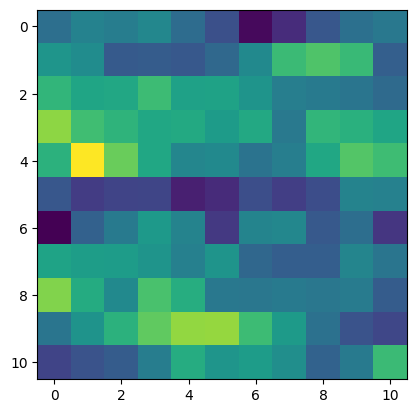

In [76]:
plt.imshow(XZ_plane)



In [77]:

plotter = pv.Plotter(notebook=False)# ,off_screen=True) # Need to add this parameter to save the screenshot

n_contours = 10
min_val = 0
max_val = pressure_field.max()
levels = np.linspace(min_val, max_val, n_contours)
iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
plotter.add_mesh(
    iso_mesh,
    scalars="Pressure",  # use the scalar to color surfaces
    cmap="jet",                   # color map
    opacity='linear',                  # solid surfaces
    show_scalar_bar=True,
    scalar_bar_args={"title": "Pressure",
        "vertical": True,
        "title_font_size": 16,
        "label_font_size": 12,
        "position_x": 0.9,
        "position_y": 0.2,
        "height": 0.3,
    },
    label="Pressure PII",
    color = "r", # color of the mesh
)

plotter.add_axes()              # show XYZ axes
plotter.show_grid()             # show grid

plotter.show()